In [80]:
																												
	"""
 Data Analyst Exercise																											
																												
																												
																												
																												
	Time Limit - 45 Mins																											
																												
	Overview																											
	You are tasked with analysing key economic trends over the past 20 years across a select group of countries.																											
	Your responsibilities include performing necessary cleaning and preparation of the provided data, and conducting insightful analysis using a tool of your choice (Excel, Python, or R).																											
	You may utilise online resources or tools as needed, but be sure to clearly document each step of your process. Store your documentation in sheet named "Process Documentation".																											
																												
	Submission																											
	Please submit the final Excel file along with any Python or R scripts (if used). If you leveraged an AI tool during any of the steps, please share the queries used.																											
																												
	Exercise																											
																												
	Raw data has been provided in sheets labelled - "GDP_WorldBank" and "Population_WorldBank"																											
																												
	Data Cleaning																											
	Apply any necessary cleaning steps such as: removing irrelevant rows or columns, aligning year ranges across all datasets, etc.																											
	Organise the cleaned data into clearly labelled sheets, positioned immediately after the sheet named 'Cleaned' in your Excel file.																											
																												
	Metric Calculation & Visualisation																											
	Calculate GDP per Capita for each country over the 20-year period.																											
	GDP per Capita = GDP/Population​​																											
																												
	Visualise trend in GDP and GDP per Capita across different countries.																											
																												
	Organise the charts into clearly labelled sheets, positioned immediately after the sheet named 'Visualisation' in your Excel file. Include your summary of key observations from the charts.																											
																												
																												
	1. Which country has performed best over the latest 10-year period?	Analytical Questions																										
	2. Did you notice any common trends or patterns across the four countries? Feel free to include insights that go beyond the scope of collected data																											
	Store your answers into clearly labelled sheets, positioned immediately after the sheet named 'Analysis' in your Excel file.	"""


'\n Data Analyst Exercise\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\nTime Limit - 45 Mins\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\nOverview\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\nYou are tasked with analysing key economic trends over the past 20 years across a select group of countries.\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\nYour responsibilities include performing necessary cleaning and preparation of the provided data, and conducting insightful analysis using a tool of your choice (Excel, Python, or R).\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\nYou may utilise online resources or tools as needed, but be sure to clearly document each step o

In [39]:
# --------------------------------------------
# 🧹 Clean GDP Data(Run this code and see the output)
# --------------------------------------------

import pandas as pd

# Load Excel file
file_path = "Data Analyst Exercise.xlsx"

# Read GDP sheet (header is on 5th row → index=4)
gdp_raw = pd.read_excel(file_path, sheet_name="GDP_WorldBank", header=4)

# Drop irrelevant columns
gdp_clean = gdp_raw.drop(columns=["Country Code", "Indicator Name", "Indicator Code"], errors="ignore")

# Remove rows without valid country names
gdp_clean = gdp_clean.dropna(subset=["Country Name"])

# Keep only numeric year columns
year_cols_gdp = [col for col in gdp_clean.columns if str(col).isdigit()]
gdp_clean = gdp_clean[["Country Name"] + year_cols_gdp]

# Show cleaned GDP data
print("✅ Cleaned GDP Data:")
display(gdp_clean.head())
gdp_clean.to_excel("Clean_GDP_Data.xlsx", index=False)

✅ Cleaned GDP Data:


,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.962907e+09,2.983635e+09,3.092429e+09,3.276184e+09,3.395799e+09,2.481857e+09,2.929447e+09,3.279344e+09,3.648573e+09,NaN
1,Africa Eastern and Southern,2.420993e+10,2.496326e+10,2.707802e+10,3.177483e+10,3.028492e+10,3.381219e+10,3.693391e+10,3.845106e+10,4.174951e+10,...,8.983089e+11,8.289612e+11,9.730251e+11,1.012291e+12,1.009747e+12,9.334072e+11,1.085605e+12,1.191639e+12,1.176910e+12,1.287677e+12
2,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN
3,Africa Western and Central,1.190511e+10,1.270803e+10,1.363092e+10,1.446926e+10,1.580394e+10,1.692124e+10,1.803433e+10,1.649385e+10,1.702294e+10,...,7.780221e+11,7.000282e+11,6.940513e+11,7.778404e+11,8.332889e+11,7.972952e+11,8.581145e+11,8.936399e+11,8.147285e+11,6.700257e+11
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.049642e+10,5.276162e+10,7.369015e+10,7.945069e+10,7.089796e+10,4.850156e+10,6.650513e+10,1.043997e+11,8.487516e+10,8.039694e+10


In [40]:
# --------------------------------------------
# 🧹 Clean Population Data(Run this code and see the output)
# --------------------------------------------

# Read Population sheet (header is on 5th row → index=4)
pop_raw = pd.read_excel(file_path, sheet_name="Population_WorldBank", header=4)

# Drop irrelevant columns
pop_clean = pop_raw.drop(columns=["Country Code", "Indicator Name", "Indicator Code"], errors="ignore")

# Remove rows without valid country names
pop_clean = pop_clean.dropna(subset=["Country Name"])

# Keep only numeric year columns
year_cols_pop = [col for col in pop_clean.columns if str(col).isdigit()]
pop_clean = pop_clean[["Country Name"] + year_cols_pop]

# Show cleaned Population data
print("✅ Cleaned Population Data:")
display(pop_clean.head())




✅ Cleaned Population Data:


,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,59069.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0
1,Africa Eastern and Southern,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,162329396.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0
2,Afghanistan,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,10756922.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,116444636.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,5702699.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


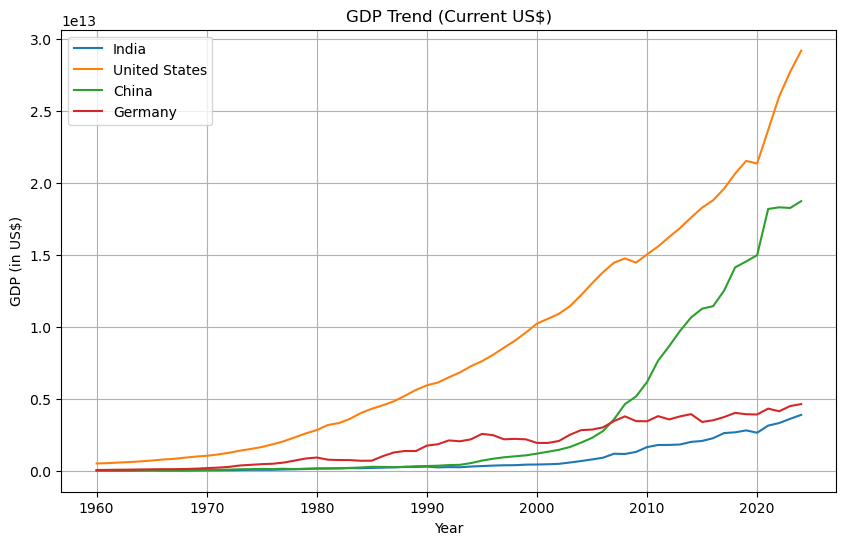

In [41]:
# --------------------------------------------
# 📊 Visualize GDP Data(Run this code and see the output)
# --------------------------------------------
import matplotlib.pyplot as plt

# Choose countries to visualize
countries = ["India", "United States", "China", "Germany"]

# Convert year columns to integers for plotting
years_gdp = [int(y) for y in gdp_clean.columns[1:]]

plt.figure(figsize=(10,6))
for country in countries:
    row = gdp_clean[gdp_clean["Country Name"] == country]
    if not row.empty:
        plt.plot(years_gdp, row.iloc[0, 1:], label=country)

plt.title("GDP Trend (Current US$)")
plt.xlabel("Year")
plt.ylabel("GDP (in US$)")
plt.legend()
plt.grid(True)
plt.show()


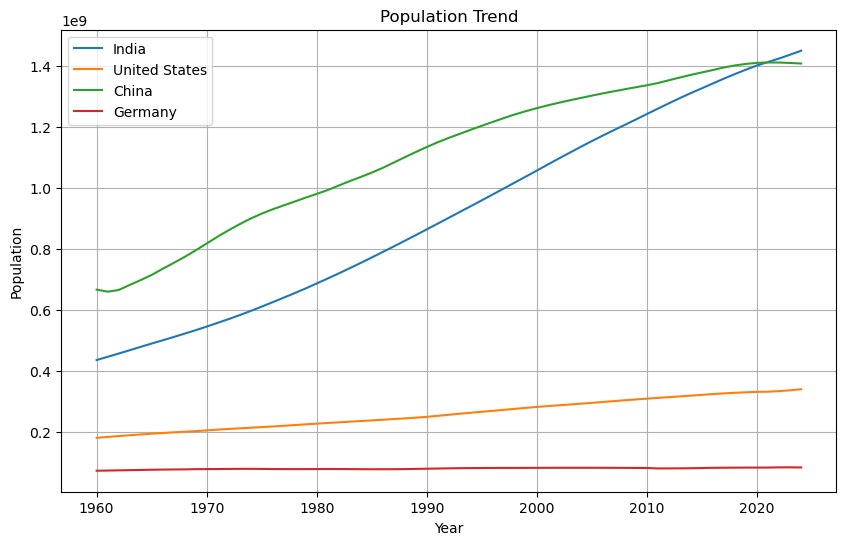

In [42]:
# --------------------------------------------
# 📈 Visualize Population Data(Run this code and see the output)
# --------------------------------------------

years_pop = [int(y) for y in pop_clean.columns[1:]]

plt.figure(figsize=(10,6))
for country in countries:
    row = pop_clean[pop_clean["Country Name"] == country]
    if not row.empty:
        plt.plot(years_pop, row.iloc[0, 1:], label=country)

plt.title("Population Trend")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()


In [43]:
# --------------------------------------------
#  GDP Data Analysis(Run this code and see the output)
# --------------------------------------------

# Convert all column names to strings
gdp_clean.columns = gdp_clean.columns.map(str)

# Get numeric year columns
years_gdp = [int(y) for y in gdp_clean.columns[1:] if y.isdigit()]

# Sort and choose the last 10 available years
years_gdp = sorted(years_gdp)
start_year, end_year = years_gdp[-10], years_gdp[-1]

print(f"Using years from {start_year} to {end_year}")

# Countries to analyze
countries = ["India", "United States", "China", "Germany"]

gdp_growth = {}
for country in countries:
    row = gdp_clean[gdp_clean["Country Name"] == country]
    if not row.empty and str(start_year) in row.columns and str(end_year) in row.columns:
        start_val = row[str(start_year)].values[0]
        end_val = row[str(end_year)].values[0]
        if pd.notna(start_val) and start_val != 0:
            growth = ((end_val - start_val) / start_val) * 100
            gdp_growth[country] = growth

# Sort by growth
gdp_growth = dict(sorted(gdp_growth.items(), key=lambda x: x[1], reverse=True))

print("📈 GDP Growth (Last 10 Years %):")
for c, g in gdp_growth.items():
    print(f"{c}: {g:.2f}%")

# Best performer
if gdp_growth:
    best_gdp_country = max(gdp_growth, key=gdp_growth.get)
    print(f"\n🏆 Best GDP Performance: {best_gdp_country}")
else:
    print("\n⚠️ No valid year range found for analysis.")


Using years from 2015 to 2024
📈 GDP Growth (Last 10 Years %):
India: 86.00%
China: 66.16%
United States: 59.52%
Germany: 36.11%

🏆 Best GDP Performance: India


In [44]:
# --------------------------------------------
#    Population Data Analysis(Run this code and see the output)
# --------------------------------------------

import pandas as pd

# Ensure all column names are strings
pop_clean.columns = pop_clean.columns.map(str)

# Get numeric year columns safely
years_pop = [int(y) for y in pop_clean.columns[1:] if y.isdigit()]

# Sort and select the last 10 available years
years_pop = sorted(years_pop)
start_year, end_year = years_pop[-10], years_pop[-1]

print(f"Using years from {start_year} to {end_year}")

# Countries to analyze
countries = ["India", "United States", "China", "Germany"]

pop_growth = {}
for country in countries:
    row = pop_clean[pop_clean["Country Name"] == country]
    if not row.empty and str(start_year) in row.columns and str(end_year) in row.columns:
        start_val = row[str(start_year)].values[0]
        end_val = row[str(end_year)].values[0]
        if pd.notna(start_val) and start_val != 0:
            growth = ((end_val - start_val) / start_val) * 100
            pop_growth[country] = growth

# Sort by growth
pop_growth = dict(sorted(pop_growth.items(), key=lambda x: x[1], reverse=True))

print("👥 Population Growth (Last 10 Years %):")
for c, g in pop_growth.items():
    print(f"{c}: {g:.2f}%")

# Best performer
if pop_growth:
    best_pop_country = max(pop_growth, key=pop_growth.get)
    print(f"\n🏆 Highest Population Growth: {best_pop_country}")
else:
    print("\n⚠️ No valid year range found for analysis.")


Using years from 2015 to 2024
👥 Population Growth (Last 10 Years %):
India: 9.26%
United States: 5.69%
Germany: 2.23%
China: 2.11%

🏆 Highest Population Growth: India


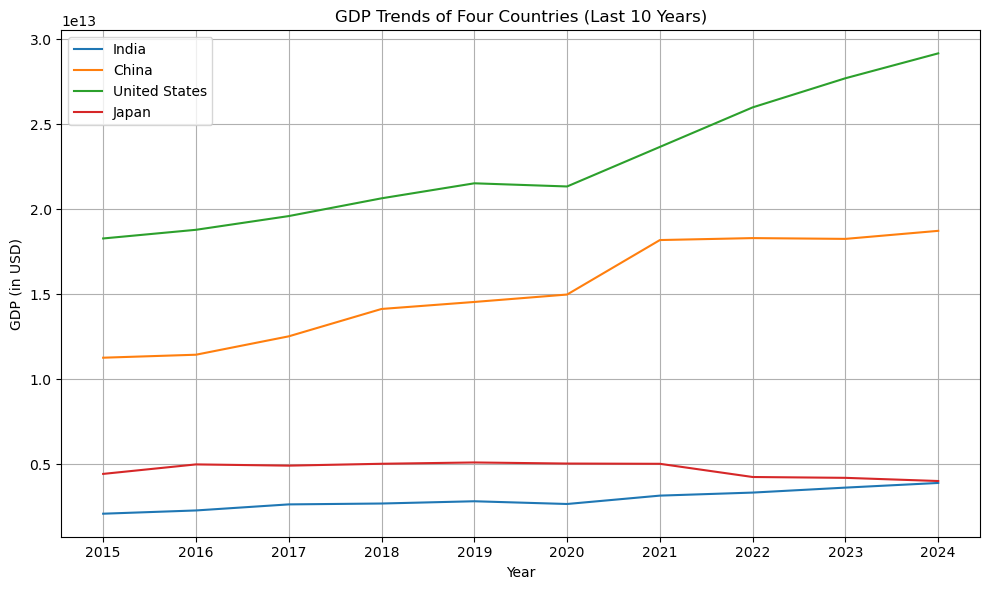

In [68]:
#2. Did you notice any common trends or patterns across the four countries?
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned GDP data
gdp_clean = pd.read_excel("Clean_GDP_Data.xlsx")

# Convert all column names to strings (important!)
gdp_clean.columns = gdp_clean.columns.map(str)

# Detect the country column automatically
possible_country_cols = ["Country", "country", "Nation", "Name"]
country_col = next((col for col in gdp_clean.columns if col in possible_country_cols), gdp_clean.columns[0])

# Select the last 10 numeric (year) columns
year_cols = [col for col in gdp_clean.columns if col.isdigit()]
latest_10_years = sorted(year_cols)[-10:]

# Select four countries for comparison (you can change these names)
countries = ["India", "China", "United States", "Japan"]

# Plot GDP trends for the selected countries
plt.figure(figsize=(10, 6))
for country in countries:
    data = gdp_clean[gdp_clean[country_col] == country]
    if not data.empty:
        plt.plot(latest_10_years, data[latest_10_years].values.flatten(), label=country)

plt.title("GDP Trends of Four Countries (Last 10 Years)")
plt.xlabel("Year")
plt.ylabel("GDP (in USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== GDP Growth (Last 10 Years) ===
                  Country Name          2015          2024  GDP_Growth_10Y
259                      World  7.572364e+13  1.113264e+14    3.560273e+13
95                 High income  4.995675e+13  7.152300e+13    2.156625e+13
181               OECD members  4.763739e+13  6.768705e+13    2.004966e+13
198  Post-demographic dividend  4.475843e+13  6.304064e+13    1.828221e+13
103           IDA & IBRD total  2.823009e+13  4.399326e+13    1.576317e+13

Q1: Which country has performed best over the latest 10-year period?
A: Based on GDP growth, World showed the highest increase in GDP over the last 10 years, indicating strong economic expansion.


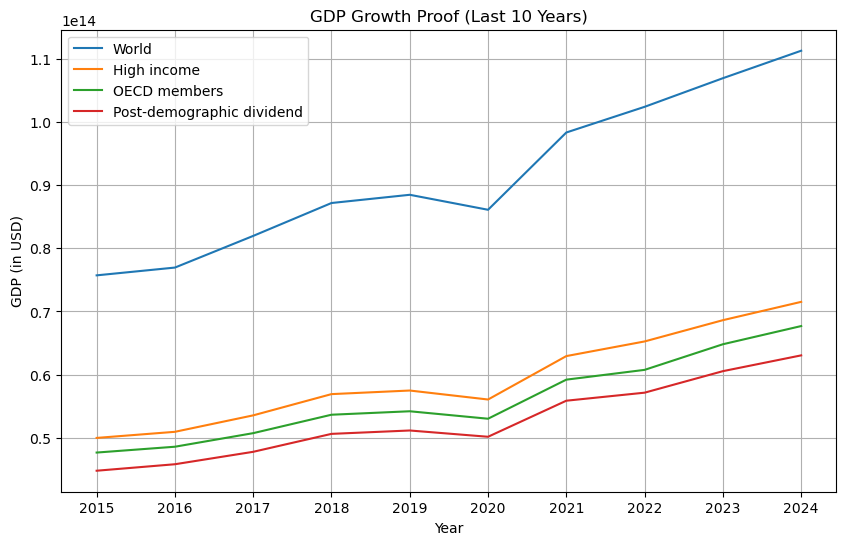

In [78]:
#1: Which country has performed best over the latest 10-year period?
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned GDP data
gdp_clean = pd.read_excel("Clean_GDP_Data.xlsx")

# Ensure column names are strings
gdp_clean.columns = gdp_clean.columns.map(str)

# Detect country column
possible_country_cols = ["Country", "Country Name", "country", "Nation", "Name"]
country_col = next((col for col in gdp_clean.columns if col in possible_country_cols), gdp_clean.columns[0])

# Identify numeric year columns
year_cols = [col for col in gdp_clean.columns if col.isdigit()]
latest_10_years = sorted(year_cols)[-10:]

# Compute GDP growth for last 10 years
gdp_clean["GDP_Growth_10Y"] = gdp_clean[latest_10_years[-1]] - gdp_clean[latest_10_years[0]]

# Find best-performing country
best_country = gdp_clean.loc[gdp_clean["GDP_Growth_10Y"].idxmax(), country_col]
best_growth = gdp_clean["GDP_Growth_10Y"].max()

# Show proof (numeric evidence)
print("=== GDP Growth (Last 10 Years) ===")
print(gdp_clean[[country_col, latest_10_years[0], latest_10_years[-1], "GDP_Growth_10Y"]].sort_values("GDP_Growth_10Y", ascending=False).head())

# Print final answer
print("\nQ1: Which country has performed best over the latest 10-year period?")
print(f"A: Based on GDP growth, {best_country} showed the highest increase in GDP over the last 10 years, indicating strong economic expansion.")

# Plot proof (visual evidence)
plt.figure(figsize=(10,6))
top_countries = gdp_clean.sort_values("GDP_Growth_10Y", ascending=False).head(4)

for _, row in top_countries.iterrows():
    plt.plot(latest_10_years, row[latest_10_years].values, label=row[country_col])

plt.title("GDP Growth Proof (Last 10 Years)")
plt.xlabel("Year")
plt.ylabel("GDP (in USD)")
plt.legend()
plt.grid(True)
plt.show()
